In [3]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

import geopandas as gpd

# these libraries are not dependencies of pymc

import networkx as nx
import nutpie
import libpysal as ps

In [4]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [5]:
current_path = os.getcwd()

In [10]:
state_abbs_usa = ["MA","OH","TN","TX"]

Processing state: MA


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


Shape of the combined data: (14, 89)


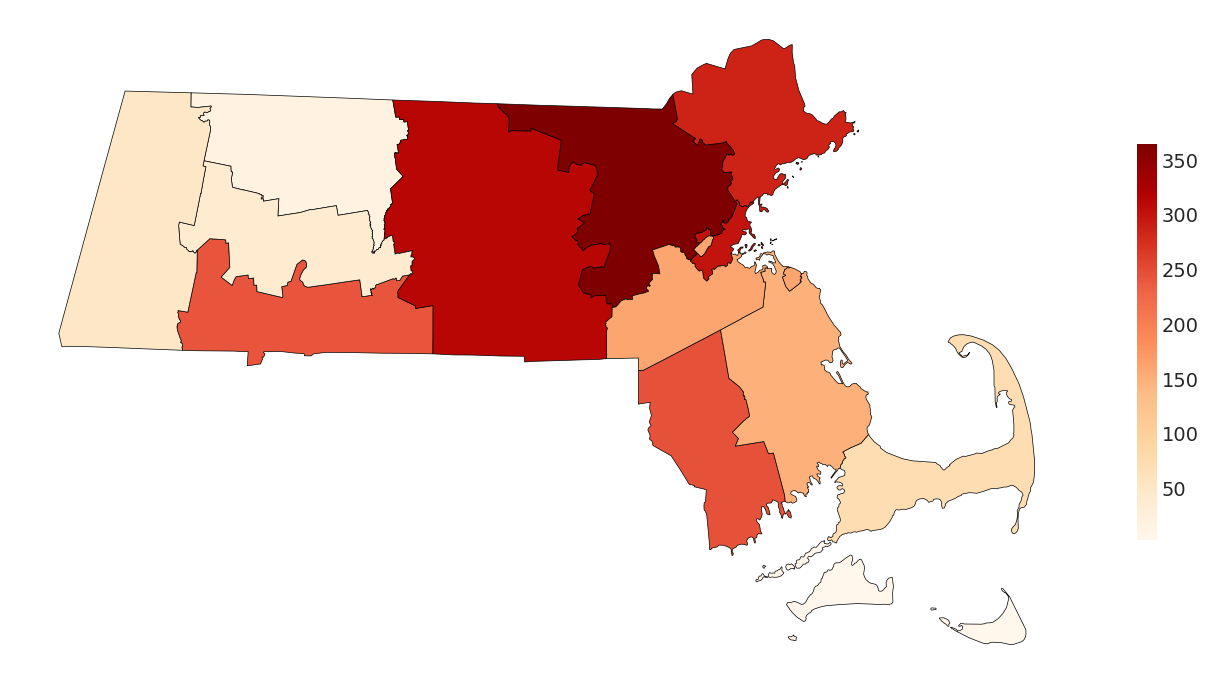

Processing state: OH


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


Shape of the combined data: (88, 89)


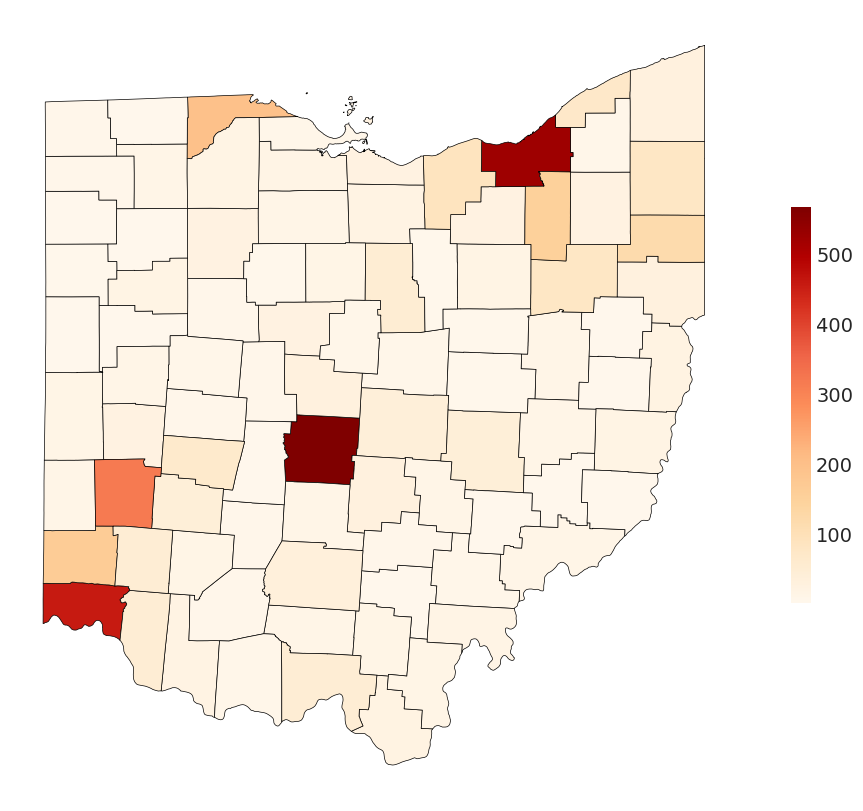

Processing state: TN


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


Shape of the combined data: (95, 89)


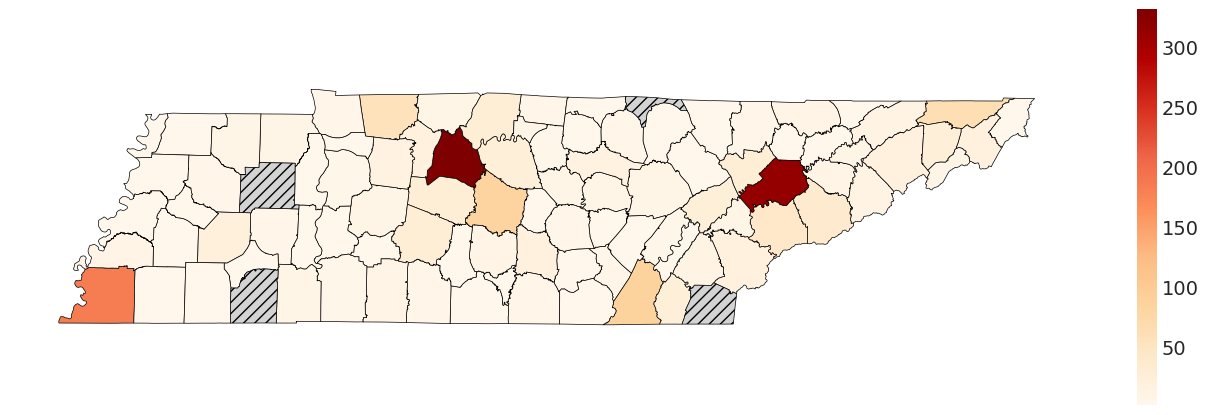

Processing state: TX


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


Shape of the combined data: (254, 89)


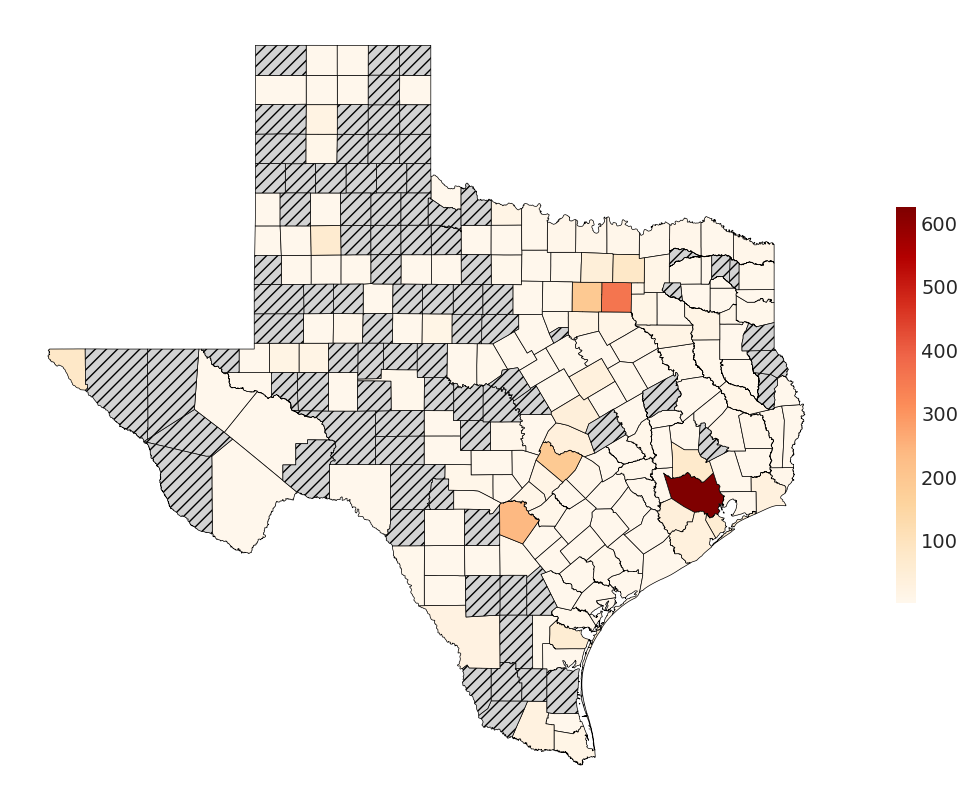

In [13]:
for state_abb in state_abbs_usa:
    state_abb_lower = state_abb.lower()
    print(f"Processing state: {state_abb}")
    # Further processing can be done here for each state

    # # SVI
    svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

    # SMR
    smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

    # GEO: get geometry data
    geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

    geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

    # combine smr on FIPS and svi data on STCNTY - left
    combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

    # merge combined data with geo data
    combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

    # print the shape
    print(f"Shape of the combined data: {combined_data.shape}")

    # Adding this just to plot original data!
    # Replace 0 with NaN in observed_deaths column
    combined_data_map = combined_data.copy()
    combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

    gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

    import matplotlib.pyplot as plt
    import geopandas as gpd

    # plot a map with observed death counts
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
    ax.set_facecolor("white")  # set axes background to white

    gdf_map.plot(
        column="observed_deaths", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},  # Makes the legend smaller
        # Style for NaN values:
        missing_kwds={
            "color": "lightgrey",       # fill color for NaN
            "edgecolor": "black",       # edge color for NaN polygons
            "hatch": "///",             # add hatching for NaN
            "label": "No Data"          # adds entry in legend
        }
    )   
    # Remove axis ticks for a cleaner map visualization
    ax.set_xticks([])
    ax.set_yticks([]) 
    plt.show()



